In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [ ]:
# # REWRITE TO WORK WITH NETCDF FILES!
# def read_mat_data(filepath):
#     import scipy.io
    
#     rd = scipy.io.loadmat(filepath) # load the mat file
#     PDATA = rd['PDATA']
#     TWT = rd['TWT']
    
#     return PDATA, TWT

In [2]:
def subtract_skycal(RADARGRAM, skycal_avg_vec):
    # INPUTS:
    # - radargram
    # - column vector of average skycal values
    # OUTPUT:
    # - skycal subtracted radargram

    skycal_array = np.tile(skycal_avg_vec, RADARGRAM.shape[1]) # create a skycal array of the same shape as the rd
    print(skycal_array.shape)

    skycal_corrected = RADARGRAM-skycal_array # subtract the skycal values
    
    return skycal_corrected

def apply_range_gain(RADARGRAM):
    ylen = RADARGRAM.shape[0] # grab the ydimension
    yvec = np.arange(1,ylen+1) # create a vector starting at 1 through the maximum index (ylen)

    # different shapes of range multiplier vector:
    # range_multiplier = np.array(1/(yvec**2))
    # range_multiplier = np.array(1/np.sqrt(yvec))
    # range_multiplier = np.array(np.flip(yvec)/np.max(yvec)) # linear
    range_multiplier = np.array(np.log(np.flip(yvec))) # logarithmic
    plt.plot(range_multiplier); plt.title('range multiplier')
    plt.show()

    fig, (ax1,ax2) = plt.subplots(2,1,figsize=(14,14)) # initialize a figure to show before and after
    ax1.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,100), cmap='Greys_r')
    ax1.set_title("before range gain correction")

    RADARGRAM = RADARGRAM * np.transpose([range_multiplier]) # CORRECTION

    # show after range gain correction
    ax2.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
    ax2.set_title("after range gain correction")
    plt.show()

    return RADARGRAM

def remove_flats(RADARGRAM, minval, noise_thresh=1.0):
#     fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,6)) # initialize a figure to show before and after
#     ax1.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
#     ax1.set_title("before removing flat reflectors")
    
    yidxs = np.arange(0,RADARGRAM.shape[0]) # rows
    for yidx in yidxs:
        row = RADARGRAM[yidx,:] # grab the row
        # plt.plot(row); plt.show() # visualize (optional)

        # if the full noise range is less than the threshold, remove the reflector 
        if (np.nanmax(row) - np.nanmin(row)) <= noise_thresh: # inclusive noise threshold
            RADARGRAM[yidx,:] = np.ones(RADARGRAM.shape[1])*minval # replace original values with the minval in the radargram
#     # show before and after
#     ax2.imshow(RADARGRAM, vmin=np.percentile(RADARGRAM,50), vmax=np.percentile(RADARGRAM,98), cmap='Greys_r')
#     ax2.set_title("after removing flat reflectors")
#     plt.show()

    return RADARGRAM

In [31]:
datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/'
ncfiles = glob.glob(datapath+'*.nc')
ncfiles.sort()
ncfiles

['/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_01.nc',
 '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_02.nc',
 '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_03.nc',
 '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_04.nc',
 '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_05.nc',
 '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_06.nc',
 '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_07.nc',
 '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_08.nc',
 '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan20

# No sky calibration and process in batches

In [32]:
SKYCAL = False # default is no skycal

batchsize = 10 # SET BATCHSIZE IN NUMBER OF FILES

In [33]:
nbatches = int(np.ceil(len(ncfiles)/batchsize))
digits = 2
if nbatches > 100:
    digits = 3
elif nbatches > 1000:
    print('too many batches')
print(nbatches, 'batches')

2 batches


1
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_01.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_02.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_03.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_04.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_05.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_06.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_07.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_08.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_09.nc
/Users/jukesliu/D

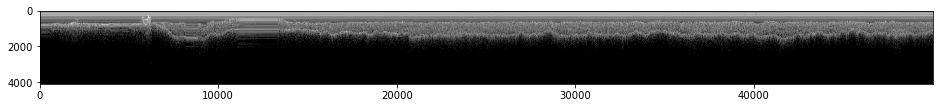

(4096, 8200)
(4096, 29788)
(4096, 39960)
(4096, 39960)
(4096, 39960)
(4096, 29336)
(4096, 36452)
(4096, 36096)
(4096, 38740)
(4096, 37464)


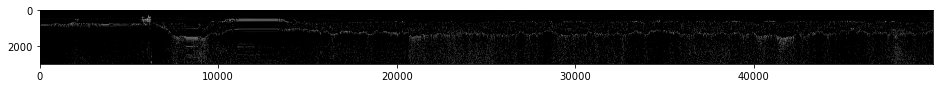

1.0156249999999999e-11
2
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_11.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_12.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_13.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_14.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_15.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_16.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_17.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_18.nc
/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start/gm29Jan2020_start_

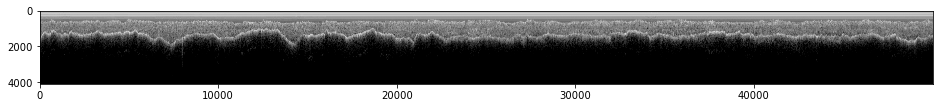

(4096, 39960)
(4096, 38144)
(4096, 38568)
(4096, 36744)
(4096, 33124)
(4096, 23400)
(4096, 21600)
(4096, 34544)
(4096, 25868)


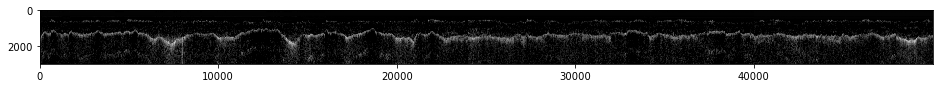

1.0156249999999999e-11


In [34]:
for batch_num in range(1,nbatches+1): # for each batch
#     if batch_num < 3: # skip some
#         continue
    print(batch_num)
    batch_str = str(batch_num).zfill(digits)
    if nbatches == 1: # if only 1 batch, do not create a subfolder
        newfolder = datapath # use existing folder
    else:
        newfolder = datapath[:-1]+'_'+batch_str+'/'
        if not os.path.exists(newfolder): # create subfolder!
            os.mkdir(newfolder)
        
    # split batch files by index
    if batch_num == 1:
        i0 = 0
    else:
        i0 = batch_num*batchsize-batchsize
    i1 = batchsize*batch_num
    batch_files = ncfiles[i0:i1]
    
    # stitch all batch radagrams together
    radargrams = []; xs = []; ys = []
    for file in batch_files:
        # grab all radargram sections
        print(file)
        ds = xr.open_dataset(file, engine="netcdf4")
        rd = ds.PDATA; x = ds.UTMx; y = ds.UTMy
        rd1 = rd # skip skycal and flat correction
        radargrams.append(rd1); xs.append(x); ys.append(y)  
    all_rd = np.hstack(radargrams) 
    radargrams = [] # ERASE TO SAVE SPACE

    # flatten and stack x,y coordinates
    xs_flattened = np.array([]); ys_flattened = np.array([])
    for xi in xs:
        xs_flattened = np.append(xs_flattened, xi)
    for yi in ys:
        ys_flattened = np.append(ys_flattened, yi)
        
    # show all radargrams stacked and test subsets
    plt.figure(figsize=(16,5))
    plt.imshow(all_rd[:,0:50000],vmin=np.percentile(all_rd,50), 
               vmax=np.percentile(all_rd,100), cmap='Greys_r')
    plt.show()
    
    # CALCULATE MEAN/MEDIAN TRACE AND SAVE
    skycal_file = 'all_median.csv'
    skycal_avg_vec = np.nanmedian(all_rd,axis=1).reshape(len(all_rd),1) # use all_rd
    pd.DataFrame(list(zip(skycal_avg_vec)),columns=['skycal_mean_vals']).to_csv(newfolder+skycal_file)
        
    # use skycal_avg_vec to CALIBRATE RD
    radargrams = []; xs = []; ys = []
    for file in batch_files:
        ds = xr.open_dataset(file, engine="netcdf4")
        rd = ds.PDATA; x = ds.UTMx; y = ds.UTMy

        # subtract skycal
        rd_skycal = subtract_skycal(rd, skycal_avg_vec)
        # remove flats
        rd1 = remove_flats(rd_skycal, np.percentile(rd_skycal,50), np.std(rd_skycal)*2)
        del rd_skycal

        radargrams.append(rd1); xs.append(x); ys.append(y) # append
        del rd1
    all_rd = np.hstack(radargrams) 
    radargrams = [] # ERASE TO SAVE SPACE 
        
    # CROP VERTICALLY
    hmin_idx = 3000 # keep everything above this vertical index
    all_rd = all_rd[:hmin_idx]

    # re-show calibrated & subsetradagram
    plt.figure(figsize=(16,5))
    plt.imshow(all_rd[:,:50000],vmin=np.percentile(all_rd,50), 
               vmax=np.percentile(all_rd,100), cmap='Greys_r')
    plt.show()

    # SAVE ALL TO NPY FILES
    np.save(newfolder+'preprocessed_stitched_rd.npy', all_rd)
    np.save(newfolder+'preprocessed_stitched_rd_xs.npy', xs_flattened)
    np.save(newfolder+'preprocessed_stitched_rd_ys.npy', ys_flattened)
    
    # EXPORT TWT FACTOR
    filepath = glob.glob(datapath+'*.nc')[0]
    ds = xr.open_dataset(filepath, engine="netcdf4")
    TWT = ds.TWT; TWT_interval = np.mean(np.diff(TWT))
    print(TWT_interval)
    TWT_df = pd.DataFrame(TWT, columns=['TWT']); TWT_df.to_csv(newfolder+'TWT_vector.csv')

# OLD CODE:

### Sky calibration

In [ ]:
# Compile all skycal sections from code
SKYCAL = False # default is no skycal
files_skycal = glob.glob(datapath+'*_skycal_idxs.csv')

if len(files_skycal) > 0:
    print('Skycal files found.')
    SKYCAL = True # signify that SKYCAL has been found
    
    skycal_traces = []
    for file in files_skycal:
        skycal_df = pd.read_csv(file); skycal_idxs = skycal_df.skycal_idxs # read in skycal indexes
        fname = file.split('/')[-1]
        print(fname)
        
        for file in ncfiles:
            radargram_file = datapath+fname[:-16]+'.nc'
            if os.path.exists(radargram_file):
                ds = xr.open_dataset(file, engine="netcdf4")
                PDATA = ds.PDATA; skycal_idxs = ds.skycal_idxs
                # grab skycal traces
                for i in skycal_idxs:
                    skycal_traces.append(PDATA[:,i-1]) # grab the skycal trace

            skycal_section = np.stack(skycal_traces,axis=1)
else:
    print('No skycal files found. Use median or mean trace subtraction at the end of the script.')

In [ ]:
if SKYCAL: 
    # show skycal sections
    plt.figure(figsize=(14,5))
    plt.imshow(skycal_section,vmin=np.percentile(skycal_section,50), vmax=np.percentile(skycal_section,100), cmap='Greys_r')
    plt.show()
    
    # calculate the average skycal section as a vector
    skycal_avg_vec = np.nanmedian(skycal_section,axis=1).reshape(len(skycal_section),1)

    # save skycal vector to CSV
    pd.DataFrame(list(zip(skycal_avg_vec)),
                 columns=['skycal_mean_vals']).to_csv(datapath+'skycal.csv')

## Preprocessing functions

In [ ]:
if SKYCAL: # if skycal was done,
    skycal_file = 'skycal.csv'
else: # if not skycal, then use the mean/median trace
    skycal_file = 'all_median.csv'
#     skycal_file = 'all_mean.csv'
print('use skycal file:', skycal_file)

In [ ]:
# read in skycal vector
if os.path.exists(datapath+skycal_file): # if it exists
    skycal_df = pd.read_csv(datapath+skycal_file).skycal_mean_vals
    skycal_avg_vec = []
    for sc in skycal_df:
        sc_float = float(sc[1:-1])
    #     skycal_avg_vec.append(sc_float)
        skycal_avg_vec.append(sc_float*1.0) # subtract a fraction of the skycal value
    skycal_avg_vec = np.array(skycal_avg_vec,dtype=float).reshape(len(skycal_avg_vec),1) # reshape into a column vector
    
    # perform the sky calibration and flat correction
    radargrams = []; xs = []; ys = []
    for file in ncfiles:
        ds = xr.open_dataset(file, engine="netcdf4")
        rd = ds.PDATA; x = ds.UTMx; y = ds.UTMy

        # subtract skycal
        rd_skycal = subtract_skycal(rd, skycal_avg_vec)
        fig, (ax1, ax2) = plt.subplots(2,1,figsize=(6,6))
        ax1.imshow(rd, vmin=np.percentile(rd,50), vmax=np.percentile(rd,100), cmap='Greys_r')
        ax2.imshow(rd_skycal,  vmin=np.percentile(rd_skycal,50), vmax=np.percentile(rd_skycal,100),cmap='Greys_r')
        ax1.set_title('original rd'); ax2.set_title('skycal correction')
        plt.show()

        # remove flats
        rd1 = remove_flats(rd_skycal, np.percentile(rd_skycal,50), np.std(rd_skycal)*2)
        del rd_skycal

        radargrams.append(rd1); xs.append(x); ys.append(y) # append
        
        del rd1
elif not os.path.exists(datapath+skycal_file) and not SKYCAL:
    print('must generate mean/median trace file.')
    # grab all radargram sections
    radargrams = []; xs = []; ys = []
    for file in ncfiles:
        print(file)
        ds = xr.open_dataset(file, engine="netcdf4")
        rd = ds.PDATA; x = ds.UTMx; y = ds.UTMy
        rd1 = rd # skip skycal and flat correction
        radargrams.append(rd1); xs.append(x); ys.append(y)  

## Stitch them together horizontally

In [ ]:
# horzontal concatenate
all_rd = np.hstack(radargrams) 
radargrams = [] # ERASE TO SAVE SPACE

# flatten and stack x,y coordinates
xs_flattened = np.array([]); ys_flattened = np.array([])
for xi in xs:
    xs_flattened = np.append(xs_flattened, xi)
for yi in ys:
    ys_flattened = np.append(ys_flattened, yi)

In [ ]:
# show all radargrams stacked and test subsets
plt.figure(figsize=(16,5))
plt.imshow(all_rd[:,140000:200000],vmin=np.percentile(all_rd,50), 
           vmax=np.percentile(all_rd,100), cmap='Greys_r')
plt.show()

In [ ]:
if not SKYCAL and not os.path.exists(datapath+skycal_file): # CALCULATE MEAN/MEDIAN TRACE 
    skycal_avg_vec = np.nanmedian(all_rd,axis=1).reshape(len(all_rd),1) # use all_rd

    # save skycal vector to CSV
    pd.DataFrame(list(zip(skycal_avg_vec)),
                 columns=['skycal_mean_vals']).to_csv(datapath+skycal_file)
# now rerun processing code!

## Subset horizontally and vertically

# EDIT ALL CODE TO READ SPLIT PREPROCESSED DATA

In [ ]:
# crop horizontally and vertically
xmin_idx = 0; xmax_idx = len(xs_flattened)
hmin_idx = 4000 # keep everything above this vertical index

all_rd = all_rd[:hmin_idx,xmin_idx:xmax_idx]
# skycal_avg_vec = skycal_avg_vec[:hmin_idx,xmin_idx:xmax_idx] # keep upper portion of skycal as well
# xs_flattened = xs_flattened[xmin_idx:xmax_idx]
# ys_flattened = ys_flattened[xmin_idx:xmax_idx]

In [ ]:
# save coordinates
np.save(datapath+'preprocessed_stitched_rd_xs.npy', xs_flattened)
np.save(datapath+'preprocessed_stitched_rd_ys.npy', ys_flattened)

In [ ]:
# save array
np.save(datapath+'preprocessed_stitched_rd.npy', all_rd)

In [ ]:
# grab TWT
filepath = glob.glob(datapath+'*v2.nc')[0]
ds = xr.open_dataset(filepath, engine="netcdf4")
TWT = ds.TWT
TWT_interval = np.mean(np.diff(TWT))
print(TWT_interval)

In [ ]:
# export TWT vector
TWT_df = pd.DataFrame(TWT, columns=['TWT'])
TWT_df.to_csv(datapath+'TWT_vector.csv')
TWT_df

### Grab a section of data to export

In [ ]:
datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed_bigDrift/'
rdfiles = glob.glob(datapath+'rd*_preprocessed.npy')
rdfiles.sort()

In [ ]:
xs = np.load(datapath+'preprocessed_stitched_rd_xs.npy') # load the xs
ys = np.load(datapath+'preprocessed_stitched_rd_ys.npy') # load the ys

In [ ]:
targetfiles = []; rd_nums = []
for rdfile in rdfiles:
    rd_id = rdfile.split('/')[-1].split('_')[0]
    rd_num = int(rd_id[2:])
    if rd_num >= 26 and rd_num <=35:
        targetfiles.append(rdfile)
        rd_nums.append(rd_num)
targetfiles

In [ ]:
radargrams = []; xs = []; ys = []
for file in targetfiles:
    rd1 = np.load(file) # load the file
    dimension = rd1.shape[0] # grab the square dimensino
    
    rd_id = file.split('/')[-1].split('_')[0]
    rd_num = int(rd_id[2:])
    print(rd_num)
    new_xs = xs[rd_num*dimension:rd_num*dimension+dimension]
    new_ys = ys[rd_num*dimension:rd_num*dimension+dimension]


In [ ]:
rd1.shape

In [ ]:
new_rd = np.hstack(radargrams) 

In [ ]:
# show all radargrams stacked and test subsets
plt.figure(figsize=(16,5))
plt.imshow(new_rd[:,10000:20000],cmap='Greys_r')
# plt.imshow(subtract_skycal(new_rd, skycal_avg_vec)[:,30000:],cmap='Greys_r')
plt.show()

In [ ]:
# calculate skycal vec
skycal_avg_vec = np.nanmedian(new_rd,axis=1).reshape(len(new_rd),1) # use all_rd

# save skycal vector to CSV
pd.DataFrame(list(zip(skycal_avg_vec)),columns=['skycal_mean_vals']).to_csv(outpath+skycal_file)

In [ ]:
# if os.path.exists(outpath+skycal_file): # if it exists
#     skycal_df = pd.read_csv(outpath+skycal_file).skycal_mean_vals
#     skycal_avg_vec = []
#     for sc in skycal_df:
#         sc_float = float(sc[1:-1])
#     #     skycal_avg_vec.append(sc_float)
#         skycal_avg_vec.append(sc_float*1.0) # subtract a fraction of the skycal value
#     skycal_avg_vec = np.array(skycal_avg_vec,dtype=float).reshape(len(skycal_avg_vec),1) # reshape into a column vector    
new_rd = subtract_skycal(new_rd, skycal_avg_vec)

#### Select specific files

In [ ]:
datapath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed_bigDrift_rd26to35/'

In [ ]:
rd2 = np.load(datapath+'rd08_preprocessed.npy')
xs = np.load(datapath+'preprocessed_stitched_rd_xs.npy') # load the xs
ys = np.load(datapath+'preprocessed_stitched_rd_ys.npy') # load the ys

In [ ]:
plt.imshow(rd2); plt.show()

In [ ]:
xs[8*dimension:]

In [ ]:
dimension = rd2.shape[0]

new_xs = np.array([]); new_ys = np.array([])
for rd_num in rd_nums:
    print(rd_num*dimension, rd_num*dimension+dimension)
    new_xs = np.append(new_xs, xs[rd_num*dimension:rd_num*dimension+dimension])
    new_ys = np.append(new_ys, ys[rd_num*dimension:rd_num*dimension+dimension])

In [ ]:
# load specific file
new_rd = np.load(datapath+'rd48_preprocessed.npy')
plt.imshow(new_rd); plt.show()

In [ ]:
new_rd.shape

In [ ]:
new_rd[:,:new_rd.shape[0]]

In [ ]:
plt.imshow(new_rd[:,:new_rd.shape[0]]); plt.show()

In [ ]:
xs = np.load(datapath+'preprocessed_stitched_rd_xs.npy') # load the xs
ys = np.load(datapath+'preprocessed_stitched_rd_ys.npy') # load the ys

new_xs = np.array([]); new_ys = np.array([])
for rd_num in rd_nums:
    print(rd_num*dimension, rd_num*dimension+dimension)
    new_xs = np.append(new_xs, xs[rd_num*dimension:rd_num*dimension+dimension])
    new_ys = np.append(new_ys, ys[rd_num*dimension:rd_num*dimension+dimension])

In [ ]:
# make new folder
outpath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed_bigDrift_rd26to35/'
if not os.path.exists(outpath):
    os.mkdir(outpath)

In [ ]:
# np.save(outpath+'preprocessed_stitched_rd_xs.npy', new_xs)
# np.save(outpath+'preprocessed_stitched_rd_ys.npy', new_ys)
np.save(outpath+'preprocessed_stitched_rd.npy', new_rd)